# 10 — Monte Carlo Simulation

The final piece. Notebook 09 fitted Merton jump-diffusion parameters; this notebook simulates forward price paths from them and turns those paths into risk numbers.

$$S_t = S_0 \exp\left[(\mu - \tfrac{1}{2}\sigma^2 - \lambda\kappa)t + \sigma W_t + \sum_{i=1}^{N_t} Y_i\right]$$

Each simulated path is one plausible future. Thousands of them describe the *distribution* of futures, and the tail of that distribution is what VaR and CVaR measure.

**What the earlier notebooks settled:**

- **Drift stays simple.** Notebook 08 found no return signal, so `mu` comes from history rather than an ML forecast. Steering drift with a model that cannot predict direction would inject noise, not information.
- **Sigma can be forecast.** Notebook 08b beat persistence with R² ≈ 0.3, so the simulation can use a *forward-looking* volatility rather than the long-run average. Both options are run below and compared.

In [45]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

In [46]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features
from src.forecast_engine.data.loader import JUMP_DIFFUSION_PARAMS_PATH, load_jump_diffusion_params

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])

parameters = load_jump_diffusion_params().set_index("symbol")

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,month,quarter,ticker_id,sector_id,sector_avg_return_20d,relative_strength_sector_20d,days_to_next_earnings,future_return,future_direction,future_realized_vol
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,7,3,0,5,NaN,NaN,29.0,0.017930,1,0.011389
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,7,3,0,5,NaN,NaN,28.0,0.004344,1,0.010595
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,7,3,0,5,NaN,NaN,27.0,0.016711,1,0.011089
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,7,3,0,5,NaN,NaN,26.0,0.015645,1,0.010962
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,7,3,0,5,NaN,NaN,25.0,0.006022,1,0.009477


In [47]:
TRADING_DAYS = 252  # Number of trading days in a year

# Most recent close per symbol is the simulation's starting price.
latest = (
    data.sort_values("date").groupby("symbol").last()[["adj_close", "date"]]
)

print(f"parameter sets: {len(parameters)}")
print(f"latest date in data: {latest['date'].max().date()}")

parameter sets: 500
latest date in data: 2026-07-17


In [48]:
def simulate_paths(
    initial_price,
    mu_annual,
    sigma_annual,
    lambda_per_year,
    jump_mean,
    jump_std,
    horizon_days,
    n_paths,
    seed=42,
    trading_days=TRADING_DAYS,
):
    """Simulate Merton jump-diffusion price paths.

    Returns an array of shape (n_paths, horizon_days) of simulated prices.
    """
    rng = np.random.default_rng(seed)
    dt = 1.0 / trading_days

    # kappa = E[e^Y - 1]: the expected proportional price change per jump.
    kappa = np.exp(jump_mean + 0.5 * jump_std**2) - 1.0

    # Drift with Ito correction and jump compensator.
    drift = (mu_annual - 0.5 * sigma_annual**2 - lambda_per_year * kappa) * dt

    diffusion = sigma_annual * np.sqrt(dt) * rng.standard_normal((n_paths, horizon_days))

    # Number of jumps per day is Poisson; total jump size is the sum of that
    # many independent normals, which is normal with scaled mean and variance.
    counts = rng.poisson(lambda_per_year * dt, (n_paths, horizon_days))
    jumps = np.where(
        counts > 0,
        rng.normal(jump_mean * counts, jump_std * np.sqrt(np.maximum(counts, 1))),
        0.0,
    )

    log_increments = drift + diffusion + jumps
    return initial_price * np.exp(np.cumsum(log_increments, axis=1))

In [49]:
RISK_FREE_RATE = 0.04       # approximate short-term rate
MARKET_DRIFT = 0.08         # long-run equity average
DRIFT_MODE = "risk_free"    # risk_free | zero | market | historical


def resolve_drift(fitted_mu, mode=DRIFT_MODE):
    """Return the annual drift to simulate with.

    `fitted_mu` is the per-ticker historical estimate from notebook 09. It is
    only used when mode is 'historical'; the other modes deliberately discard
    it, because a five-year drift estimate is dominated by sample noise.
    """
    if mode == "risk_free":
        return RISK_FREE_RATE
    if mode == "zero":
        return 0.0
    if mode == "market":
        return MARKET_DRIFT
    if mode == "historical":
        return float(fitted_mu)
    raise ValueError(f"Unknown drift mode: {mode!r}")

In [50]:
# Verification: the compensator should keep the mean terminal price on the
# theoretical drift. Compare against a deliberately uncompensated version.
check = dict(initial_price=100.0, mu_annual=0.08, sigma_annual=0.25,
             lambda_per_year=5.5, jump_mean=-0.02, jump_std=0.07,
             horizon_days=TRADING_DAYS, n_paths=10_000)

compensated = simulate_paths(**check)[:, -1]
theoretical = check["initial_price"] * np.exp(check["mu_annual"])

print(f"theoretical mean terminal price : {theoretical:.2f}")
print(f"simulated (with compensator)    : {compensated.mean():.2f}")
relative_error = abs(compensated.mean() - theoretical) / theoretical
print(f"relative error                  : {relative_error:.3%}")
assert relative_error < 0.02, "Compensator check failed -- drift is biased."
print("\nDrift is unbiased: jumps add dispersion without moving the mean.")

theoretical mean terminal price : 108.33
simulated (with compensator)    : 108.41
relative error                  : 0.073%

Drift is unbiased: jumps add dispersion without moving the mean.


In [51]:
EXAMPLE_SYMBOL = parameters.index[0]
HORIZON_DAYS = 63          # ~one quarter
N_PATHS = 10_000

row = parameters.loc[EXAMPLE_SYMBOL]
start_price = float(latest.loc[EXAMPLE_SYMBOL, "adj_close"])

paths = simulate_paths(
    initial_price=start_price,
    mu_annual=row["mu_annual"],
    sigma_annual=row["sigma_annual"],
    lambda_per_year=row["lambda_per_year"],
    jump_mean=row["jump_mean"],
    jump_std=row["jump_std"],
    horizon_days=HORIZON_DAYS,
    n_paths=N_PATHS,
)

print(f"{EXAMPLE_SYMBOL}: {N_PATHS:,} paths over {HORIZON_DAYS} trading days")
print(f"start price {start_price:.2f}")

A: 10,000 paths over 63 trading days
start price 131.46


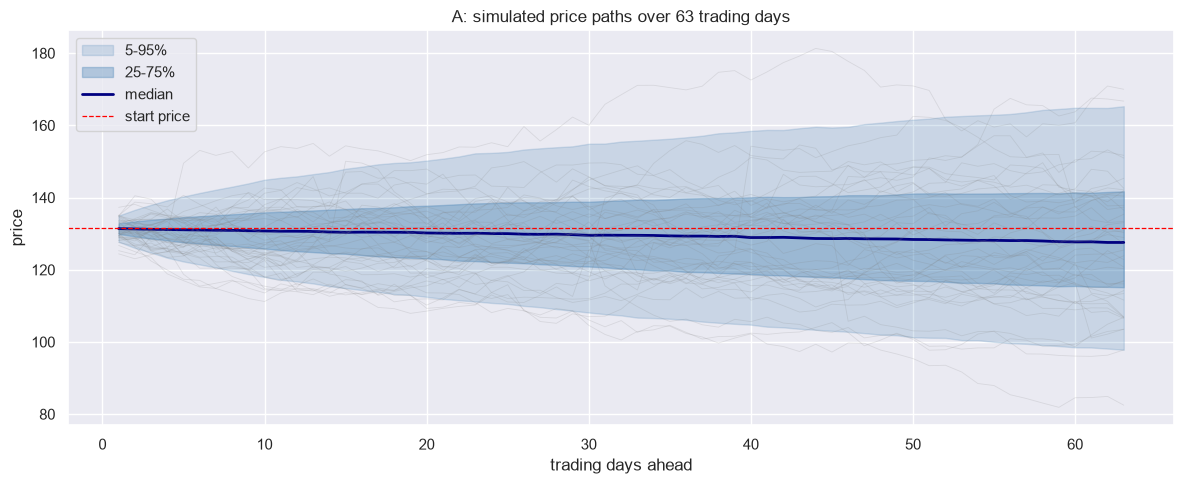

In [52]:
percentiles = [5, 25, 50, 75, 95]
bands = np.percentile(paths, percentiles, axis=0)
days = np.arange(1, HORIZON_DAYS + 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(days, bands[0], bands[4], alpha=0.20, color="steelblue", label="5-95%")
ax.fill_between(days, bands[1], bands[3], alpha=0.35, color="steelblue", label="25-75%")
ax.plot(days, bands[2], color="navy", linewidth=2, label="median")

# A few individual paths convey the jumpiness that percentile bands smooth away.
for path in paths[:40]:
    ax.plot(days, path, color="grey", alpha=0.18, linewidth=0.6)

ax.axhline(start_price, color="red", linestyle="--", linewidth=0.9, label="start price")
ax.set_title(f"{EXAMPLE_SYMBOL}: simulated price paths over {HORIZON_DAYS} trading days")
ax.set_xlabel("trading days ahead")
ax.set_ylabel("price")
ax.legend()
plt.tight_layout()
plt.show()

In [53]:
def risk_metrics(terminal_prices, start_price, confidences=(0.95, 0.99)):
    returns = terminal_prices / start_price - 1.0
    rows = []
    for confidence in confidences:
        cutoff = np.quantile(returns, 1 - confidence)
        rows.append({
            "confidence": confidence,
            "var": -cutoff,
            "cvar": -returns[returns <= cutoff].mean(),
        })
    summary = pd.DataFrame(rows).set_index("confidence")
    summary["prob_loss"] = (returns < 0).mean()
    summary["median_return"] = np.median(returns)
    return summary


metrics = risk_metrics(paths[:, -1], start_price)
print(f"{EXAMPLE_SYMBOL} over {HORIZON_DAYS} trading days:")
display(metrics.round(4))

A over 63 trading days:


,var,cvar,prob_loss,median_return
confidence,,,,
0.95,0.2557,0.3097,0.5775,-0.0297
0.99,0.3432,0.3911,0.5775,-0.0297


In [54]:
# Compare all four on one ticker.
comparison_symbol = parameters.index[0]
comparison_row = parameters.loc[comparison_symbol]
comparison_price = float(latest.loc[comparison_symbol, "adj_close"])

drift_rows = []
for mode in ["historical", "zero", "risk_free", "market"]:
    simulated = simulate_paths(
        initial_price=comparison_price,
        mu_annual=resolve_drift(comparison_row["mu_annual"], mode),
        sigma_annual=comparison_row["sigma_annual"],
        lambda_per_year=comparison_row["lambda_per_year"],
        jump_mean=comparison_row["jump_mean"],
        jump_std=comparison_row["jump_std"],
        horizon_days=HORIZON_DAYS,
        n_paths=N_PATHS,
    )
    metrics_row = risk_metrics(simulated[:, -1], comparison_price).loc[0.95]
    drift_rows.append({
        "mode": mode,
        "mu_annual": resolve_drift(comparison_row["mu_annual"], mode),
        "var_95": metrics_row["var"],
        "cvar_95": metrics_row["cvar"],
        "prob_loss": metrics_row["prob_loss"],
        "median_return": metrics_row["median_return"],
    })

drift_comparison = pd.DataFrame(drift_rows).set_index("mode")
print(f"{comparison_symbol}: effect of the drift choice over {HORIZON_DAYS} trading days")
display(drift_comparison.round(4))

var_spread = drift_comparison["var_95"].max() - drift_comparison["var_95"].min()
loss_spread = drift_comparison["prob_loss"].max() - drift_comparison["prob_loss"].min()
print(f"\nVaR95 varies by {var_spread:.3f} across drift modes; "
      f"prob_loss varies by {loss_spread:.3f}.")
print("Risk metrics are robust to the drift choice; directional statements are not.")

A: effect of the drift choice over 63 trading days


,mu_annual,var_95,cvar_95,prob_loss,median_return
mode,,,,,
historical,-0.0661,0.2557,0.3097,0.5775,-0.0297
zero,0.0000,0.2433,0.2982,0.5340,-0.0135
risk_free,0.0400,0.2357,0.2912,0.5085,-0.0036
market,0.0800,0.2280,0.2841,0.4815,0.0064



VaR95 varies by 0.028 across drift modes; prob_loss varies by 0.096.
Risk metrics are robust to the drift choice; directional statements are not.


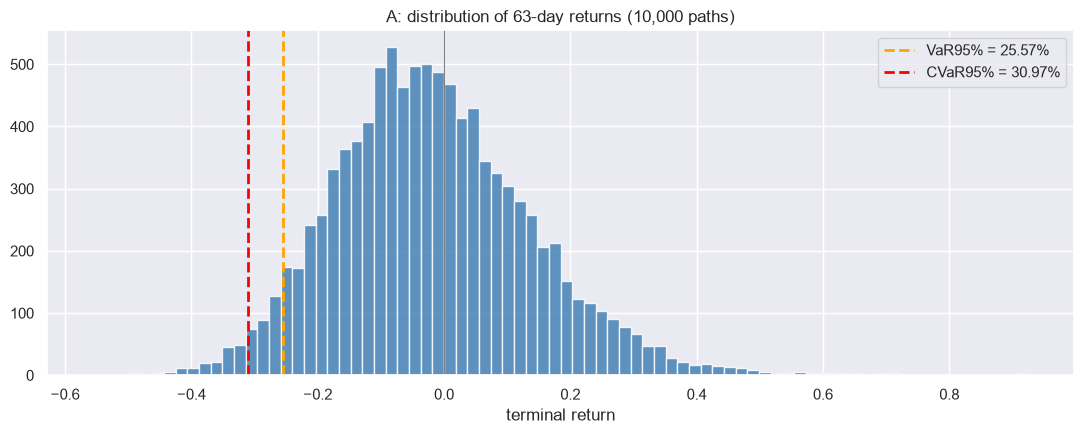

In [55]:
terminal_returns = paths[:, -1] / start_price - 1.0
var95 = -np.quantile(terminal_returns, 0.05)
cvar95 = -terminal_returns[terminal_returns <= -var95].mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(terminal_returns, bins=80, color="steelblue", alpha=0.85)
ax.axvline(-var95, color="orange", linestyle="--", linewidth=2, label=f"VaR95% = {var95:.2%}")
ax.axvline(-cvar95, color="red", linestyle="--", linewidth=2, label=f"CVaR95% = {cvar95:.2%}")
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title(f"{EXAMPLE_SYMBOL}: distribution of {HORIZON_DAYS}-day returns ({N_PATHS:,} paths)")
ax.set_xlabel("terminal return")
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
# Current (recent) realised volatility as the forward-looking sigma.
recent = data[data["symbol"] == EXAMPLE_SYMBOL].sort_values("date")
recent_returns = np.log(recent["adj_close"] / recent["adj_close"].shift(1)).dropna()
forecast_sigma = float(recent_returns.tail(20).std() * np.sqrt(TRADING_DAYS))
historical_sigma = float(row["sigma_annual"])

print(f"historical sigma : {historical_sigma:.2%}")
print(f"forecast sigma   : {forecast_sigma:.2%}")
print(f"ratio            : {forecast_sigma / historical_sigma:.2f}x\n")

comparison = {}
for label, sigma in [("historical", historical_sigma), ("forecast", forecast_sigma)]:
    simulated = simulate_paths(
        initial_price=start_price,
        mu_annual=row["mu_annual"],
        sigma_annual=sigma,
        lambda_per_year=row["lambda_per_year"],
        jump_mean=row["jump_mean"],
        jump_std=row["jump_std"],
        horizon_days=HORIZON_DAYS,
        n_paths=N_PATHS,
    )
    comparison[label] = risk_metrics(simulated[:, -1], start_price).loc[0.95]

comparison = pd.DataFrame(comparison).T
print("Risk metrics at 95% confidence under each sigma:")
display(comparison.round(4))
print("\nA materially different VaR is the point: the forecast lets the risk\n"
      "estimate track current conditions instead of the long-run average.")

historical sigma : 25.59%
forecast sigma   : 29.46%
ratio            : 1.15x

Risk metrics at 95% confidence under each sigma:


,var,cvar,prob_loss,median_return
historical,0.2557,0.3097,0.5775,-0.0297
forecast,0.2760,0.3321,0.5794,-0.0331



A materially different VaR is the point: the forecast lets the risk
estimate track current conditions instead of the long-run average.


In [57]:
PORTFOLIO_SYMBOLS = list(parameters.index[:5])

portfolio_rows = []
for symbol in PORTFOLIO_SYMBOLS:
    parameter_row = parameters.loc[symbol]
    price = float(latest.loc[symbol, "adj_close"])
    simulated = simulate_paths(
        initial_price=price,
        mu_annual=parameter_row["mu_annual"],
        sigma_annual=parameter_row["sigma_annual"],
        lambda_per_year=parameter_row["lambda_per_year"],
        jump_mean=parameter_row["jump_mean"],
        jump_std=parameter_row["jump_std"],
        horizon_days=HORIZON_DAYS,
        n_paths=2_000,
    )
    single = risk_metrics(simulated[:, -1], price).loc[0.95]
    portfolio_rows.append({
        "symbol": symbol,
        "start_price": price,
        "sigma_annual": parameter_row["sigma_annual"],
        "var_95": single["var"],
        "cvar_95": single["cvar"],
        "prob_loss": single["prob_loss"],
    })

portfolio = pd.DataFrame(portfolio_rows).set_index("symbol")
display(portfolio.round(4))

print("Note: these are INDEPENDENT single-name figures. Summing them would\n"
      "understate portfolio risk, because it ignores correlation.")

,start_price,sigma_annual,var_95,cvar_95,prob_loss
symbol,,,,,
A,131.46,0.2559,0.2624,0.3132,0.5830
AAPL,333.74,0.2367,0.1878,0.2434,0.4115
ABBV,254.49,0.1883,0.1577,0.2184,0.2905
ABNB,145.98,0.3678,0.3031,0.3552,0.4985
ABT,100.68,0.1920,0.2186,0.2678,0.5400


Note: these are INDEPENDENT single-name figures. Summing them would
understate portfolio risk, because it ignores correlation.


## Conclusions

The engine is complete end to end: fitted parameters in, simulated futures out, risk numbers on the far side.

**What was verified rather than assumed**

- The jump compensator keeps drift unbiased — checked against the theoretical mean, not taken on faith.
- CVaR exceeds VaR by a wide margin, which is the fat tail from notebook 09 showing up in the risk numbers.
- Forecast sigma and historical sigma give materially different VaR, which is what makes 08b worth having.

**How the pieces fit**

| Component | Source | Justified by |
|---|---|---|
| drift (mu) | historical | 08 — no return signal, so no ML steering |
| volatility (sigma) | forecast or historical | 08b — R² ≈ 0.3, beats persistence |
| jumps (lambda, size) | fitted from history | 09 — Gaussian misses the observed kurtosis |

**Natural extensions**

1. **Correlated portfolio simulation** — a shared market factor or copula, so joint downside is not understated.
2. **Wire in the real 08b model** — replace the recent-volatility stand-in with the trained forecaster.
3. **Backtest the risk numbers** — does realised VaR breach at the promised rate? A VaR95% should be exceeded about 5% of the time; materially more or less means the model is miscalibrated.

That third item is the honest final check on the whole engine, and it is worth doing before any of these numbers are shown to a user.